## UCI SECOM Dataset - Exploratory Data Analysis

In [ ]:
## 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Everything is working!")

Everything is working!


In [ ]:
## 2. Load Dataset 

df = pd.read_csv("../data/uci-secom.csv")

df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [ ]:
## 3. Dataset Overview 

df.shape


(1567, 592)

In [ ]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


In [ ]:
## 4. Target Distribution 

df["Pass/Fail"].value_counts()

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

In [ ]:

df["Pass/Fail"].value_counts(normalize=True)

Pass/Fail
-1    0.933631
 1    0.066369
Name: proportion, dtype: float64

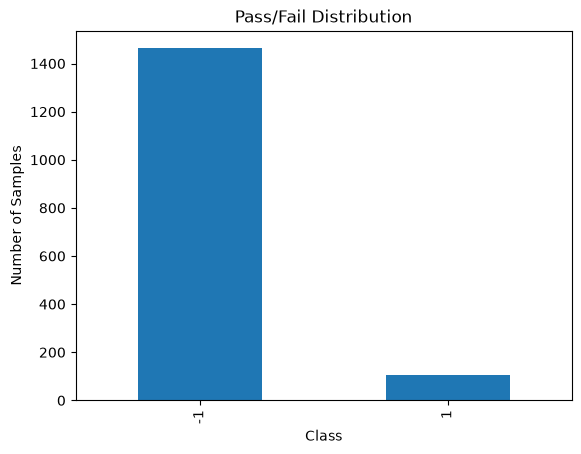

In [134]:
df["Pass/Fail"].value_counts().plot(kind="bar")

plt.title("Pass/Fail Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
## 5. Missing Value Analysis 

df.isnull().sum()

Time          0
0             6
1             7
2            14
3            14
             ..
586           1
587           1
588           1
589           1
Pass/Fail     0
Length: 592, dtype: int64

In [ ]:

df.isnull().sum().sum()

np.int64(41951)

In [ ]:

df.isnull().sum().gt(0).sum()

np.int64(538)

In [121]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False).head(10)

292    1429
157    1429
158    1429
293    1429
492    1341
220    1341
358    1341
85     1341
516    1018
517    1018
dtype: int64

In [122]:

total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()

missing_percentage = (missing_cells / total_cells) * 100

missing_percentage

np.float64(4.522219251798065)

In [ ]:
## 6. Statistical Summary 

df.describe()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


In [ ]:
## 7. Constant Feature Analysis

constant_features = df.nunique()

constant_features[constant_features <= 1]

5      1
13     1
42     1
49     1
52     1
      ..
534    1
535    1
536    1
537    1
538    1
Length: 116, dtype: int64

In [ ]:
## 8. Time Column Analysis 

df["Time"].head()

0    2008-07-19 11:55:00
1    2008-07-19 12:32:00
2    2008-07-19 13:17:00
3    2008-07-19 14:43:00
4    2008-07-19 15:22:00
Name: Time, dtype: str

In [127]:
df["Time"].describe()

count                    1567
unique                   1534
top       2008-10-15 01:52:00
freq                        3
Name: Time, dtype: object

In [ ]:
## 9. Feature and Target Separation 

X = df.drop(columns=["Time", "Pass/Fail"])
y = df["Pass/Fail"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1567, 590)
y shape: (1567,)


In [129]:
constant_cols = X.columns[X.nunique() <= 1]

X = X.drop(columns=constant_cols)

print("Removed:", len(constant_cols))
print("New X shape:", X.shape)

Removed: 116
New X shape: (1567, 474)


In [130]:
X.isnull().sum().sum()

np.int64(41136)